# Loading data and cleaning columns

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind  # For p-value calculation
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [9]:
bechdel_scores = pd.read_csv('/Users/brookeye/RISE/Bechdel_Final/Data/1. InputData/bechdel_scores.csv')
bechdel_scores['title'] = bechdel_scores['title'].str.lower()
bechdel_scores

,year,id,imdbid,title,rating
0,1874,9602,3155794.0,passage de venus,0
1,1877,9804,14495706.0,la rosace magique,0
2,1878,9603,2221420.0,sallie gardner at a gallop,0
3,1878,9806,12592084.0,le singe musicien,0
4,1881,9816,7816420.0,athlete swinging a pick,0
...,...,...,...,...,...
10557,2025,11779,29603959.0,novocaine,1
10558,2025,11785,30840798.0,"phoenician scheme, the",3
10559,2025,11786,32550101.0,straw,3
10560,2025,11787,30253473.0,materialists,3


In [10]:
title_basics = pd.read_csv('/Users/brookeye/RISE/Bechdel_Final/Data/1. InputData/title.basics.tsv', sep='\t')
title_ratings=pd.read_csv('/Users/brookeye/RISE/Bechdel_Final/Data/1. InputData/title.ratings.tsv', sep='\t')
title_all = pd.read_csv('/Users/brookeye/RISE/Bechdel_Final/Data/1. InputData/title.akas.tsv', sep='\t')
title_ratings  = title_ratings.rename(columns={'tconst': 'titleId'})
title_basics  = title_basics.rename(columns={'tconst': 'titleId'})
title_all=title_all.drop(['region', 'types', 'attributes'], axis =1)
title_all = title_all[title_all['isOriginalTitle'] == 1]
title_all=title_all.merge(title_ratings, on='titleId').merge(title_basics, on='titleId')
oscar_winning = pd.read_csv('/Users/brookeye/RISE/Bechdel_Final/Data/1. InputData/oscars_df.csv')
oscar_winning
oscar_winning=oscar_winning.drop(['Unnamed: 0', 'Oscar Year'], axis=1)
oscar_winning=oscar_winning.rename(columns={'Film' : 'title'})
oscar_winning = set(oscar_winning['title'].str.lower())
title_all['oscar'] = title_all['title'].str.lower().apply(lambda x: 1 if x in oscar_winning else 0)
title_all=title_all.drop(['isOriginalTitle', 'language', 'ordering'], axis=1)
def remove_leading_zeros(s):
    return s.lstrip('0') or '0'

title_all['titleId']=title_all['titleId'].str.replace('t', '')
title_all['titleId']= [remove_leading_zeros(num) for num in title_all['titleId']]
title_all['titleId']= title_all['titleId'].astype(int)
title_all=title_all.rename(columns={'titleId' : 'imdbid'})

/var/folders/mm/8lwyn74n6wj3qytmg8w_39bm0000gn/T/ipykernel_34002/1876048893.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  title_basics = pd.read_csv('/Users/brookeye/RISE/Bechdel_Final/Data/1. InputData/title.basics.tsv', sep='\t')


In [11]:
df = bechdel_scores.merge(title_all, on='imdbid')

In [12]:
df=df[df['titleType']=='movie']
df=df[df['numVotes']>=1000]
df=df.drop(['title_y', 'startYear', 'endYear', 'isAdult', 'primaryTitle', 'titleType', 'originalTitle', 'id'], axis=1)

df=df.rename(columns={'movie_idx' : 'movie_id', 'title_x': 'title', 'rating': 'bechdel_score', 'averageRating': 'imdb_score'})

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8980 entries, 114 to 10512
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            8980 non-null   int64  
 1   imdbid          8980 non-null   float64
 2   title           8980 non-null   object 
 3   bechdel_score   8980 non-null   int64  
 4   imdb_score      8980 non-null   float64
 5   numVotes        8980 non-null   int64  
 6   runtimeMinutes  8980 non-null   object 
 7   genres          8980 non-null   object 
 8   oscar           8980 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 701.6+ KB


In [14]:
# Assuming your DataFrame is called df and has a 'genre' column
# First get all unique genres by splitting and exploding
all_genres = df['genres'].str.split(',').explode().unique()

# Create a new DataFrame with binary columns for each genre
for genre in all_genres:
    df[f'genre_{genre}'] = df['genres'].str.contains(genre, regex=False).astype(int)

df = df.drop('genres', axis=1)

In [15]:
mask = (
    (df.get('genre_Adult', 0) != 1) & 
    (df.get('genre_News', 0) != 1) & 
    (df.get('genre_\\N', 0) != 1)
)

# Apply the filter
df = df[mask].copy()

df = df.drop(columns=['genre_Adult', 'genre_News', 'genre_\\N'], errors='ignore')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8977 entries, 114 to 10512
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               8977 non-null   int64  
 1   imdbid             8977 non-null   float64
 2   title              8977 non-null   object 
 3   bechdel_score      8977 non-null   int64  
 4   imdb_score         8977 non-null   float64
 5   numVotes           8977 non-null   int64  
 6   runtimeMinutes     8977 non-null   object 
 7   oscar              8977 non-null   int64  
 8   genre_Action       8977 non-null   int64  
 9   genre_Adventure    8977 non-null   int64  
 10  genre_Biography    8977 non-null   int64  
 11  genre_Drama        8977 non-null   int64  
 12  genre_War          8977 non-null   int64  
 13  genre_History      8977 non-null   int64  
 14  genre_Comedy       8977 non-null   int64  
 15  genre_Family       8977 non-null   int64  
 16  genre_Romance      8977 no

# Exploratory Plotting

<Figure size 1200x600 with 0 Axes>

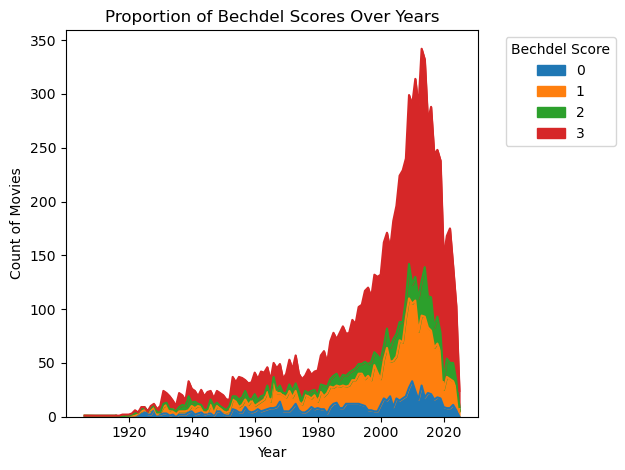

In [17]:
plt.figure(figsize=(12, 6))
df.groupby(['year', 'bechdel_score']).size().unstack().plot(kind='area', stacked=True)
plt.title('Proportion of Bechdel Scores Over Years')
plt.xlabel('Year')
plt.ylabel('Count of Movies')
plt.legend(title='Bechdel Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/mm/8lwyn74n6wj3qytmg8w_39bm0000gn/T/ipykernel_34002/387851798.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='bechdel_score', y='imdb_score', palette='coolwarm')


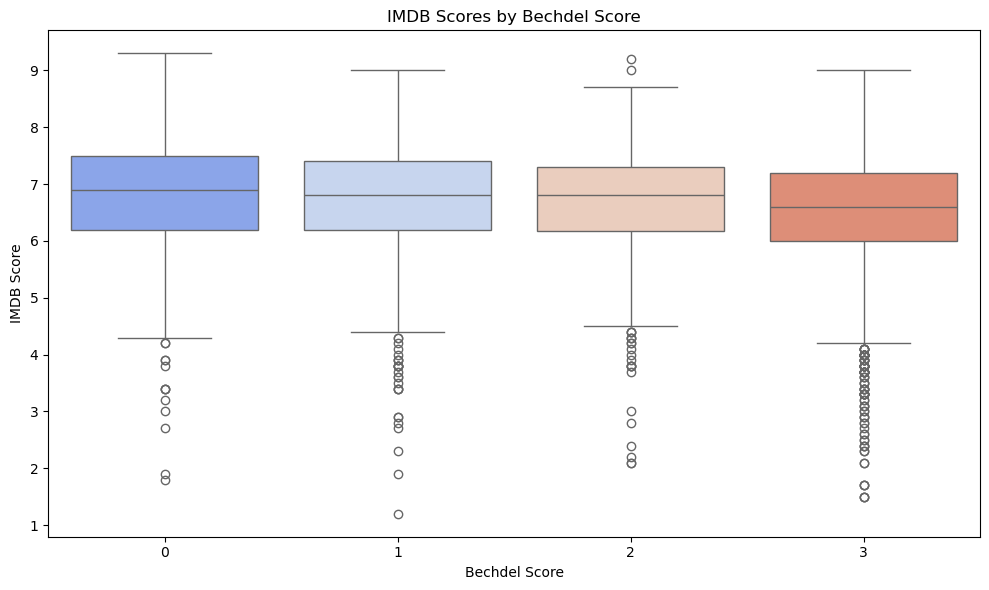

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='bechdel_score', y='imdb_score', palette='coolwarm')
plt.title('IMDB Scores by Bechdel Score')
plt.xlabel('Bechdel Score')
plt.ylabel('IMDB Score')
plt.tight_layout()
plt.show()

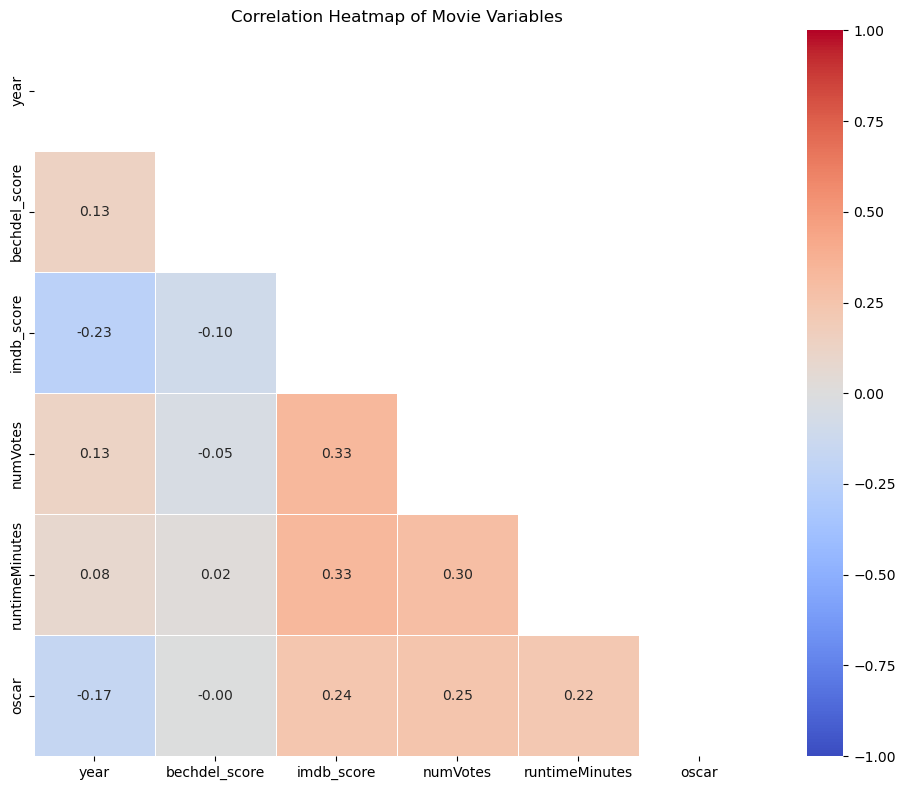

In [19]:
heatmap_df = df.copy()

# Convert 'runtimeMinutes' to numeric (handling any potential non-numeric values)
heatmap_df['runtimeMinutes'] = pd.to_numeric(heatmap_df['runtimeMinutes'], errors='coerce')

# For categorical variables, we could create dummy variables if needed
# But for simplicity, we'll just include numerical columns for this heatmap
numerical_cols = ['year', 'bechdel_score', 'imdb_score', 'numVotes', 'runtimeMinutes', 'oscar']
heatmap_df = heatmap_df[numerical_cols]

# 2. Calculate correlation matrix
corr = heatmap_df.corr()

# 3. Plot the heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Mask upper triangle for cleaner look

sns.heatmap(corr, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=.5)

plt.title('Correlation Heatmap of Movie Variables')
plt.grid(False)
plt.tight_layout()
plt.show()

## Oscar

<Figure size 800x400 with 0 Axes>

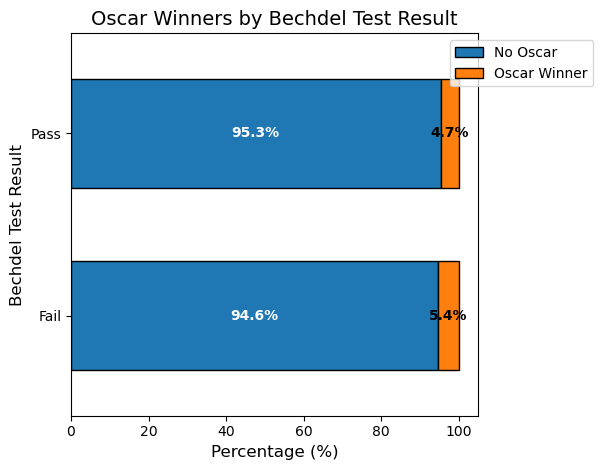

In [20]:
# Create a new DataFrame for analysis (preserves original 'df')
bechdel_oscar = pd.DataFrame({
    'bechdel_pass': df['bechdel_score'].apply(lambda x: 'Pass' if x == 3 else 'Fail'),
    'oscar': df['oscar'].map({0: 'No Oscar', 1: 'Oscar Winner'})  # Optional: Rename for clarity
})
# Compute percentages (normalized by Bechdel Pass/Fail)
cross_tab = pd.crosstab(
    index=bechdel_oscar['bechdel_pass'],
    columns=bechdel_oscar['oscar'],
    normalize='index'  # Row-wise percentages
) * 100

plt.figure(figsize=(8, 4))
ax = cross_tab.plot(
    kind='barh',
    stacked=True,
    color=['#1f77b4', '#ff7f0e'],  # Blue (No Oscar), Orange (Oscar)
    width=0.6,
    edgecolor='black'
)

# Customize the plot
plt.title('Oscar Winners by Bechdel Test Result', fontsize=14)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Bechdel Test Result', fontsize=12)
plt.legend(bbox_to_anchor=(1.3, 1), loc='upper right')  # Move legend outside
plt.grid(False)

# Add percentage labels
for i, (no_oscar, oscar) in enumerate(zip(cross_tab['No Oscar'], cross_tab['Oscar Winner'])):
    ax.text(no_oscar / 2, i, f'{no_oscar:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    ax.text(no_oscar + oscar / 2, i, f'{oscar:.1f}%', ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# Filter data (films ≥ 2000)
recent_films = df[df['year'] >= 2000].copy()
recent_films['bechdel_pass'] = recent_films['bechdel_score'].apply(lambda x: 1 if x == 3 else 0)

# Contingency table: Oscar Winner vs. Bechdel Pass/Fail
contingency_table = pd.crosstab(
    recent_films['oscar'],
    recent_films['bechdel_pass']
    
)
print(contingency_table)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject null hypothesis: Significant association exists.")
else:
    print("Fail to reject null hypothesis: No significant association.")

bechdel_pass     0     1
oscar                   
0             2111  3339
1               66    92
Chi-squared p-value: 0.4904
Fail to reject null hypothesis: No significant association.


## IMDb and Bechdel

Bechdel Score | Mean IMDb Score | 95% CI (Lower, Upper)
------------------------------------------------------
0             | 6.78 ± 0.07 | (6.72, 6.85)
1             | 6.73 ± 0.04 | (6.69, 6.77)
2             | 6.67 ± 0.06 | (6.61, 6.73)
3             | 6.55 ± 0.03 | (6.52, 6.57)


/var/folders/mm/8lwyn74n6wj3qytmg8w_39bm0000gn/T/ipykernel_34002/2660895696.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


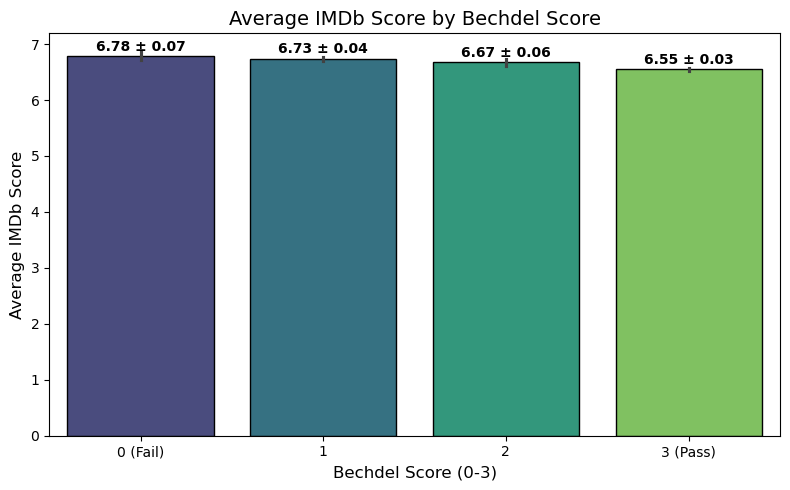

In [22]:

# Group by Bechdel score and compute mean IMDb score + 95% CI
avg_scores = df.groupby('bechdel_score')['imdb_score'].agg(['mean', 'sem'])
avg_scores['ci'] = 1.96 * avg_scores['sem']  # 95% CI = 1.96 * SEM

# Reset index for plotting
avg_scores.reset_index(inplace=True)

# Print the mean and confidence intervals
print("Bechdel Score | Mean IMDb Score | 95% CI (Lower, Upper)")
print("------------------------------------------------------")
for index, row in avg_scores.iterrows():
    lower_ci = row['mean'] - row['ci']
    upper_ci = row['mean'] + row['ci']
    print(
        f"{int(row['bechdel_score']):<13} | {row['mean']:.2f} ± {row['ci']:.2f} | "
        f"({lower_ci:.2f}, {upper_ci:.2f})"
    )

# Plotting (unchanged from your original code)
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x='bechdel_score',
    y='imdb_score',
    estimator='mean',
    errorbar=("ci", 95),
    palette='viridis',
    edgecolor='black'
)

plt.title('Average IMDb Score by Bechdel Score', fontsize=14)
plt.xlabel('Bechdel Score (0-3)', fontsize=12)
plt.ylabel('Average IMDb Score', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['0 (Fail)', '1', '2', '3 (Pass)'])
plt.grid(False)

# Add value labels on top of bars
for index, row in avg_scores.iterrows():
    plt.text(
        x=row['bechdel_score'],
        y=row['mean'] + 0.1,
        s=f"{row['mean']:.2f} ± {row['ci']:.2f}",
        ha='center',
        color='black',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [23]:
from scipy.stats import f_oneway

# Extract groups
groups = [df[df['bechdel_score'] == i]['imdb_score'] for i in range(4)]

# Perform ANOVA
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA p-value: {p_value:.30}")  # Format to 5 decimal places

ANOVA p-value: 5.63644067271612666366126298482e-19


Bechdel Result | Mean IMDb Score | 95% CI (Lower, Upper) | Sample Size
---------------------------------------------------------------
Fail           | 6.73 ± 0.03 | (6.70, 6.76) | 3897
Pass           | 6.55 ± 0.03 | (6.52, 6.57) | 5080

P-value (Fail vs Pass): 0.00000000000000000013


/var/folders/mm/8lwyn74n6wj3qytmg8w_39bm0000gn/T/ipykernel_34002/2710322617.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


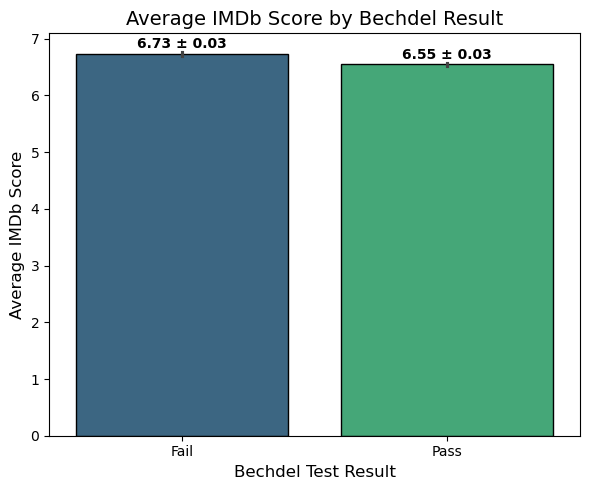

In [24]:
# Create a new column 'bechdel_result' where 0-2 = "Fail", 3 = "Pass"
df['bechdel_result'] = df['bechdel_score'].apply(lambda x: 'Fail' if x < 3 else 'Pass')

# Group by the new column and compute mean + 95% CI
avg_scores = df.groupby('bechdel_result')['imdb_score'].agg(['mean', 'sem', 'count'])
avg_scores['ci'] = 1.96 * avg_scores['sem']  # 95% CI = 1.96 * SEM
avg_scores.reset_index(inplace=True)

# Print mean and CI for each group
print("Bechdel Result | Mean IMDb Score | 95% CI (Lower, Upper) | Sample Size")
print("---------------------------------------------------------------")
for index, row in avg_scores.iterrows():
    lower_ci = row['mean'] - row['ci']
    upper_ci = row['mean'] + row['ci']
    print(
        f"{row['bechdel_result']:<14} | {row['mean']:.2f} ± {row['ci']:.2f} | "
        f"({lower_ci:.2f}, {upper_ci:.2f}) | {int(row['count'])}"
    )

# Calculate p-value using t-test
fail_scores = df[df['bechdel_result'] == 'Fail']['imdb_score']
pass_scores = df[df['bechdel_result'] == 'Pass']['imdb_score']
t_stat, p_value = ttest_ind(fail_scores, pass_scores, equal_var=False)  # Welch's t-test
print(f"\nP-value (Fail vs Pass): {p_value:.20f}")

# Plot
plt.figure(figsize=(6, 5))
sns.barplot(
    data=df,
    x='bechdel_result',
    y='imdb_score',
    estimator='mean',
    errorbar=("ci", 95),
    palette='viridis',
    edgecolor='black',
    order=['Fail', 'Pass']
)

plt.title('Average IMDb Score by Bechdel Result', fontsize=14)
plt.xlabel('Bechdel Test Result', fontsize=12)
plt.ylabel('Average IMDb Score', fontsize=12)
plt.grid(False)

# Add mean ± CI and p-value to the plot
for index, row in avg_scores.iterrows():
    plt.text(
        x=index,
        y=row['mean'] + 0.1,
        s=f"{row['mean']:.2f} ± {row['ci']:.2f}",
        ha='center',
        color='black',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## IMDb votes and Bechdel score

Runtime (minutes) by Bechdel Result (with 95% Confidence Intervals)
Fail (0-2):
  Mean runtime: 106.1 minutes
  95% CI: (105.5, 106.7)
  Sample size: 3850

Pass (3):
  Mean runtime: 105.7 minutes
  95% CI: (105.2, 106.2)
  Sample size: 5035


Hypothesis Testing Results:
t-statistic: 0.99
p-value: 0.3209929671
Cohen's d (effect size): -0.02


/var/folders/mm/8lwyn74n6wj3qytmg8w_39bm0000gn/T/ipykernel_34002/86878601.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


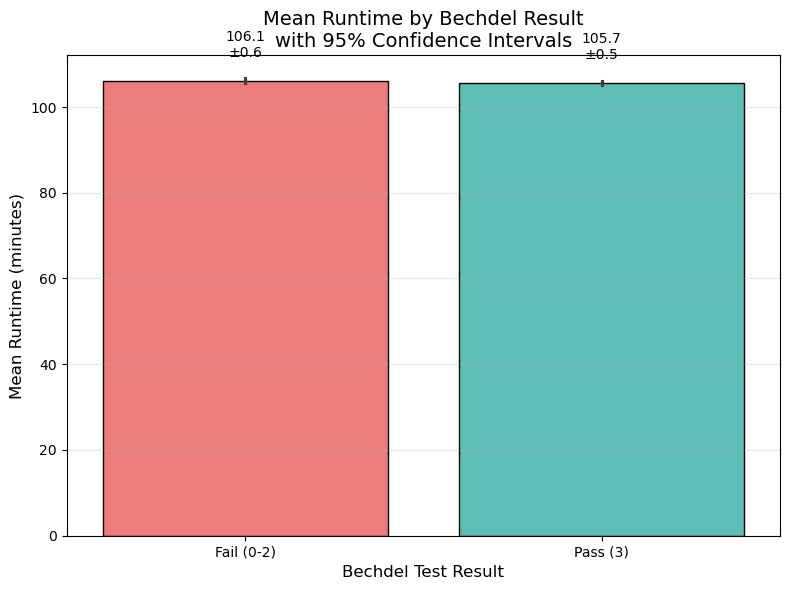

In [25]:
from scipy.stats import ttest_ind
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data - filter out extreme outliers and create Pass/Fail groups
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')
df_clean = df[(df['runtimeMinutes'] < df['runtimeMinutes'].quantile(0.99))].copy()
df_clean = df[(df['runtimeMinutes'] < df['runtimeMinutes'].quantile(0.99))].copy()
df_clean['bechdel_result'] = df_clean['bechdel_score'].apply(lambda x: 'Fail (0-2)' if x < 3 else 'Pass (3)')

# 2. Calculate mean and confidence intervals
grouped = df_clean.groupby('bechdel_result')['runtimeMinutes'].agg(['mean', 'sem', 'count'])
grouped['ci'] = 1.96 * grouped['sem']  # 95% CI
grouped.reset_index(inplace=True)

# 3. Print results
print("Runtime (minutes) by Bechdel Result (with 95% Confidence Intervals)")
print("================================================================")
for _, row in grouped.iterrows():
    print(f"{row['bechdel_result']}:")
    print(f"  Mean runtime: {row['mean']:.1f} minutes")
    print(f"  95% CI: ({row['mean']-row['ci']:.1f}, {row['mean']+row['ci']:.1f})")
    print(f"  Sample size: {row['count']}")
    print("")

# 4. Hypothesis testing (Independent t-test)
print("\nHypothesis Testing Results:")
print("==========================")

# Prepare data for t-test
fail_runtime = df_clean[df_clean['bechdel_result'] == 'Fail (0-2)']['runtimeMinutes']
pass_runtime = df_clean[df_clean['bechdel_result'] == 'Pass (3)']['runtimeMinutes']

# Welch's t-test (doesn't assume equal variances)
t_stat, p_value = ttest_ind(fail_runtime, pass_runtime, equal_var=False)

# Calculate Cohen's d for effect size
cohen_d = (pass_runtime.mean() - fail_runtime.mean()) / np.sqrt(
    (fail_runtime.std()**2 + pass_runtime.std()**2) / 2
)

print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_value:.10f}")
print(f"Cohen's d (effect size): {cohen_d:.2f}")

# 5. Create the plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=df_clean,
    x='bechdel_result',
    y='runtimeMinutes',
    estimator='mean',
    errorbar=('ci', 95),
    palette=['#ff6b6b', '#4ecdc4'],  # Red for Fail, Teal for Pass
    edgecolor='black',
    order=['Fail (0-2)', 'Pass (3)']
)

# Customize plot
plt.title('Mean Runtime by Bechdel Result\nwith 95% Confidence Intervals', fontsize=14)
plt.xlabel('Bechdel Test Result', fontsize=12)
plt.ylabel('Mean Runtime (minutes)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for _, row in grouped.iterrows():
    ax.text(
        row['bechdel_result'] == 'Pass (3)',  # 0 for Fail, 1 for Pass
        row['mean'] + row['ci'] + 5,
        f"{row['mean']:.1f}\n±{row['ci']:.1f}",
        ha='center',
        color='black',
        fontsize=10
    )

plt.tight_layout()
plt.show()

# Building baseline machine learning models

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score

### Preparing data

In [27]:
df_ml = df.drop(columns=['imdbid', 'title', 'bechdel_score'])

# Convert runtimeMinutes to numeric (handling any potential errors)
df_ml['runtimeMinutes'] = pd.to_numeric(df_ml['runtimeMinutes'], errors='coerce')

df_ml['bechdel_result'] = df['bechdel_score'].apply(lambda x: 'Fail' if x < 3 else 'Pass')

# Convert bechdel_result to binary (assuming it's categorical like 'pass'/'fail')
df_ml['bechdel_result'] = df_ml['bechdel_result'].map({'Pass': 1, 'Fail': 0})  # Adjust based on your actual values

# Separate features and target
X = df_ml.drop('bechdel_result', axis=1)
y = df_ml['bechdel_result']

# Convert object columns to numeric if needed (like runtimeMinutes)
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features (important for KNN and logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training and testing baseline logreg, knn, and random forest models

In [28]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_logreg = logreg.predict(X_test_scaled)
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_logreg))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.60      0.48      0.53       756
           1       0.67      0.76      0.71      1040

    accuracy                           0.64      1796
   macro avg       0.63      0.62      0.62      1796
weighted avg       0.64      0.64      0.64      1796



In [29]:
# Initialize and train (using default k=5)
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_knn = knn.predict(X_test_scaled)
print("\nKNN Results:")
print(classification_report(y_test, y_pred_knn))


KNN Results:
              precision    recall  f1-score   support

           0       0.53      0.49      0.51       756
           1       0.65      0.68      0.67      1040

    accuracy                           0.60      1796
   macro avg       0.59      0.59      0.59      1796
weighted avg       0.60      0.60      0.60      1796



In [30]:
# Initialize and train
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)  # No need to scale for tree-based models

# Predict and evaluate
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest Results:")
print(classification_report(y_test, y_pred_rf))


Random Forest Results:
              precision    recall  f1-score   support

           0       0.58      0.51      0.54       756
           1       0.67      0.73      0.70      1040

    accuracy                           0.64      1796
   macro avg       0.63      0.62      0.62      1796
weighted avg       0.63      0.64      0.63      1796



# Running grid_search

In [31]:
# Create a pipeline with scaling and logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

# Define the parameter grid
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'logreg__penalty': ['l1', 'l2'],  # Regularization type
    'logreg__solver': ['liblinear', 'saga'],  # Algorithms that support L1 regularization
    'logreg__class_weight': [None, 'balanced']  # Handle class imbalance
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',  # You can change to 'f1', 'accuracy', etc.
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all available cores
    verbose=1  # Show progress
)

# Fit the grid search to the data
print("Starting grid search...")
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("\nBest parameters found:")
print(best_params)

# Evaluate on test set
logreg_best_model = grid_search.best_estimator_
y_pred = logreg_best_model.predict(X_test)
y_pred_proba = logreg_best_model.predict_proba(X_test)[:, 1]  # Probabilities for class 1

print("\nTest Set Performance:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Starting grid search...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters found:
{'logreg__C': 0.01, 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}

Test Set Performance:
              precision    recall  f1-score   support

           0       0.56      0.63      0.59       756
           1       0.70      0.65      0.67      1040

    accuracy                           0.64      1796
   macro avg       0.63      0.64      0.63      1796
weighted avg       0.64      0.64      0.64      1796

Accuracy: 0.6375
ROC AUC: 0.6811


In [32]:
# Create pipeline for KNN
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # KNN is distance-based, so scaling is crucial
    ('knn', KNeighborsClassifier())
])

# Define parameter grid for KNN
knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],  # Number of neighbors
    'knn__weights': ['uniform', 'distance'],  # Weighting scheme
    'knn__p': [1, 2],  # 1=Manhattan, 2=Euclidean distance
    'knn__algorithm': ['auto', 'ball_tree', 'kd_tree']  # Algorithm for computation
}

# Initialize GridSearchCV for KNN
knn_grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring='roc_auc',  # Primary metric
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit KNN grid search
print("Starting KNN grid search...")
knn_grid_search.fit(X_train, y_train)

# Get best parameters and evaluate
knn_best_params = knn_grid_search.best_params_
print("\nBest KNN parameters:")
print(knn_best_params)

knn_best_model = knn_grid_search.best_estimator_
knn_y_pred = knn_best_model.predict(X_test)
knn_y_pred_proba = knn_best_model.predict_proba(X_test)[:, 1]

print("\nKNN Test Set Performance:")
print(classification_report(y_test, knn_y_pred))
print(f"Accuracy: {accuracy_score(y_test, knn_y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, knn_y_pred_proba):.4f}")

Starting KNN grid search...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best KNN parameters:
{'knn__algorithm': 'kd_tree', 'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'uniform'}

KNN Test Set Performance:
              precision    recall  f1-score   support

           0       0.54      0.45      0.49       756
           1       0.64      0.72      0.68      1040

    accuracy                           0.61      1796
   macro avg       0.59      0.59      0.59      1796
weighted avg       0.60      0.61      0.60      1796

Accuracy: 0.6080
ROC AUC: 0.6292


In [33]:
# Create pipeline for Random Forest
rf_pipeline = Pipeline([
    # No scaler needed for tree-based models
    ('rf', RandomForestClassifier(random_state=42))
])

# Define parameter grid for Random Forest
rf_param_grid = {
    'rf__n_estimators': [50, 100, 200],  # Number of trees
    'rf__max_depth': [None, 10, 20, 30],  # Maximum tree depth
    'rf__min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'rf__class_weight': ['balanced'],  # Handle class imbalance
    'rf__max_features': ['sqrt', 'log2', None]  # Features to consider at each split
}

# Initialize GridSearchCV for Random Forest
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit Random Forest grid search
print("Starting Random Forest grid search...")
rf_grid_search.fit(X_train, y_train)

# Get best parameters and evaluate
rf_best_params = rf_grid_search.best_params_
print("\nBest Random Forest parameters:")
print(rf_best_params)

rf_best_model = rf_grid_search.best_estimator_
rf_y_pred = rf_best_model.predict(X_test)
rf_y_pred_proba = rf_best_model.predict_proba(X_test)[:, 1]

print("\nRandom Forest Test Set Performance:")
print(classification_report(y_test, rf_y_pred))
print(f"Accuracy: {accuracy_score(y_test, rf_y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, rf_y_pred_proba):.4f}")

Starting Random Forest grid search...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Random Forest parameters:
{'rf__class_weight': 'balanced', 'rf__max_depth': 10, 'rf__max_features': 'log2', 'rf__min_samples_split': 10, 'rf__n_estimators': 200}

Random Forest Test Set Performance:
              precision    recall  f1-score   support

           0       0.59      0.59      0.59       756
           1       0.70      0.71      0.71      1040

    accuracy                           0.66      1796
   macro avg       0.65      0.65      0.65      1796
weighted avg       0.66      0.66      0.66      1796

Accuracy: 0.6576
ROC AUC: 0.7051


# SHAP Analysis

In [34]:
import shap

Logistic Regression Feature Importance and Direction


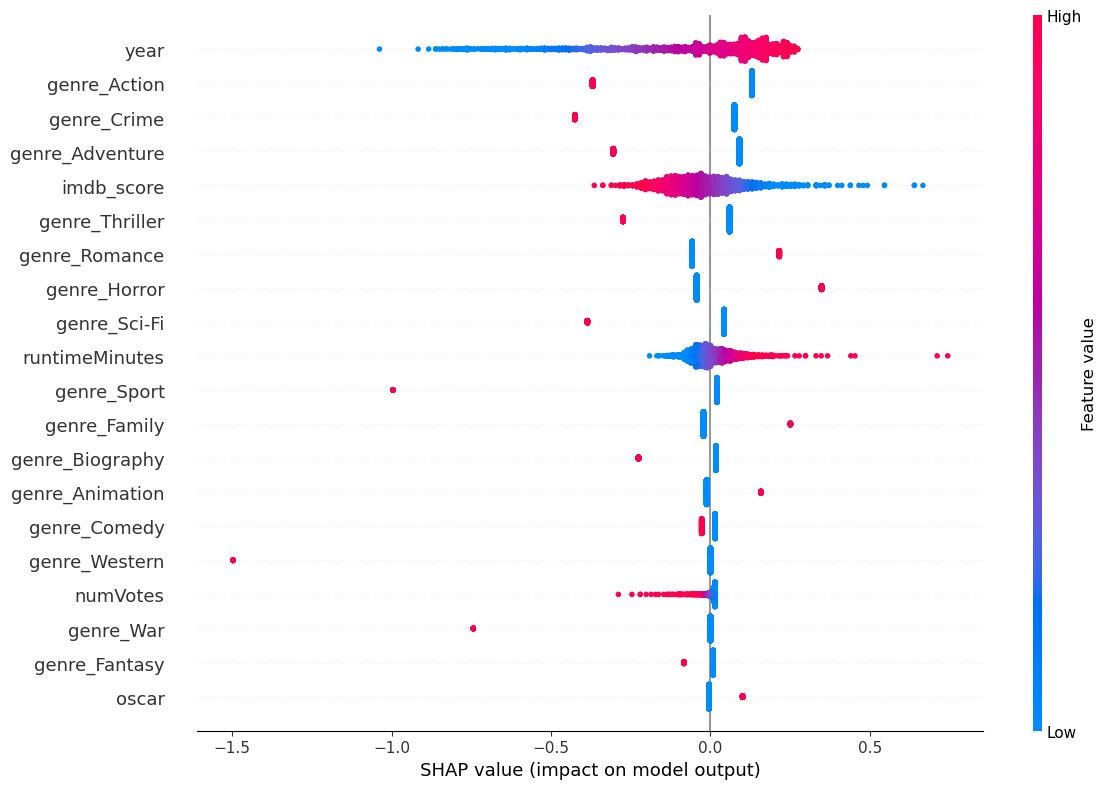

In [35]:
# Explain the model's predictions using SHAP
explainer_logreg = shap.LinearExplainer(logreg_best_model.named_steps['logreg'], X_train_scaled)
shap_values_logreg = explainer_logreg.shap_values(X_test_scaled)

# Summary plot (beeswarm plot)
print("Logistic Regression Feature Importance and Direction")
shap.summary_plot(shap_values_logreg, X_test_scaled, feature_names=X_train.columns, plot_size=(12, 8))

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:27<00:00,  2.75s/it]


<Figure size 640x480 with 0 Axes>

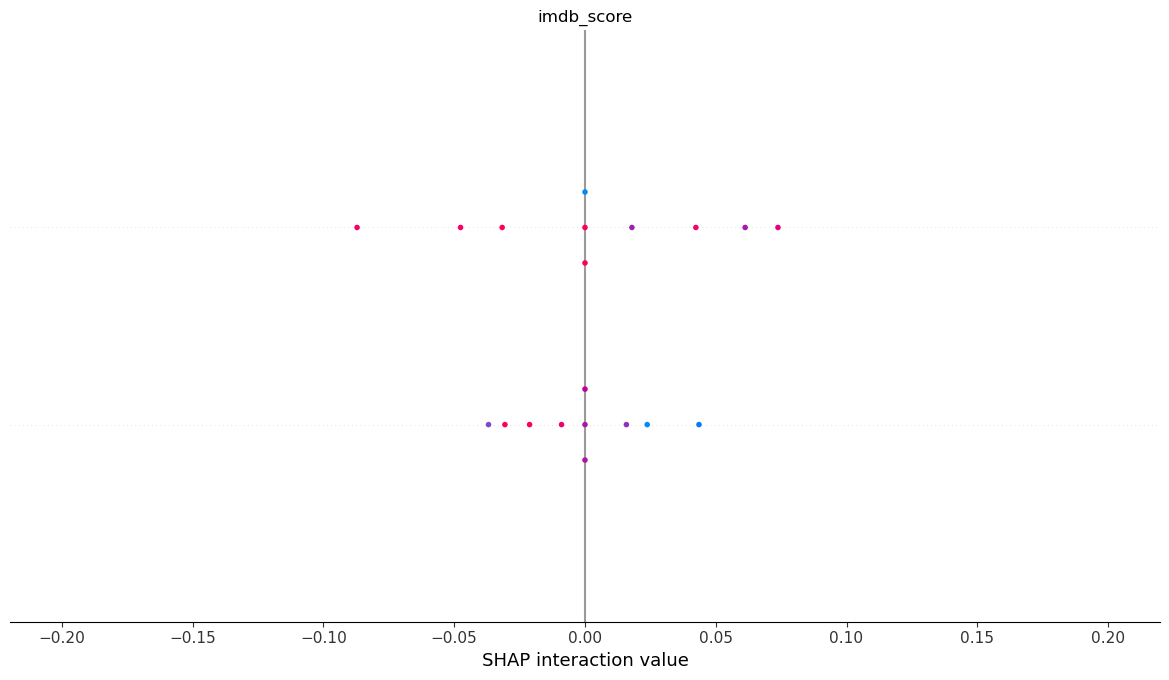

In [36]:
# Faster computation with dimension safety
explainer = shap.KernelExplainer(
    knn_best_model.named_steps['knn'].predict_proba,
    shap.sample(X_train_scaled, 10)  # Smaller background
)

# Get SHAP values for class 1 only
shap_values = explainer.shap_values(X_test_scaled[:10])  # Shape (50,27)

# Guaranteed dimension match
#assert shap_values.shape == (50, 27)
shap.summary_plot(shap_values, X_test_scaled[:10], feature_names=X_train.columns)

In [ ]:
# Faster computation with dimension safety

X_train_subset = np.random.choice(X_train_scaled, size=50, replace=False)

explainer = shap.KernelExplainer(
    knn_best_model.named_steps['knn'].predict_proba,
    X_train_subset  # Smaller background
)

X_test_subset = X_test_scaled[:5]

# Get SHAP values for class 1 only
shap_values = explainer.shap_values(X_test_subset)  # Shape (50,27)

# Guaranteed dimension match
#assert shap_values.shape == (50, 27)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X_train.columns)

ValueError: a must be 1-dimensional

In [39]:
X_train_scaled

array([[ 0.93550864,  0.8168482 , -0.4558157 , ..., -0.15095952,
        -0.09256034, -0.12414868],
       [ 0.80123593, -0.55059069,  0.59464479, ..., -0.15095952,
        -0.09256034, -0.12414868],
       [ 0.8459935 , -0.6557783 , -0.41889435, ..., -0.15095952,
        -0.09256034, -0.12414868],
       ...,
       [ 0.53269051, -0.44540309, -0.4400131 , ..., -0.15095952,
        -0.09256034, -0.12414868],
       [-1.61567288,  1.76353666,  1.21908388, ..., -0.15095952,
        -0.09256034, -0.12414868],
       [ 0.80123593,  0.08053495, -0.40547069, ..., -0.15095952,
        -0.09256034, -0.12414868]], shape=(7181, 27))

In [ ]:
# Explain the model's predictions using SHAP
explainer_rf = shap.TreeExplainer(rf_best_model.named_steps['rf'])
shap_values_rf = explainer_rf.shap_values(X_test)

# Summary plot
print("\nRandom Forest Feature Importance and Direction")
shap.summary_plot(shap_values_rf[1], X_test, feature_names=X_train.columns, plot_size=(12, 8))  # Index 1 for class 1 (PASS)

# Waterfall plot for detailed single prediction explanation
print("\nRandom Forest Detailed Prediction Breakdown")
shap.plots.waterfall(shap.Explanation(values=shap_values_rf[1][0], 
                                    base_values=explainer_rf.expected_value[1], 
                                    data=X_test.iloc[0], 
                                    feature_names=X_train.columns))


Random Forest Feature Importance and Direction


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>